# 📊 EDA — Ontario College IT Programs Dataset

**Project:** Capstone — AI-Powered Program Recommendation System  
**Dataset:** `ontario_college_IT_programs_ONLY_DEDUP_COLLEGE_PROGRAM.csv`  
**Goal:** Understand the structure, distributions, relationships, and quality of the data before modelling.

---
### Table of Contents
1. Setup & Data Loading
2. Dataset Overview & Shape
3. Missing Values & Data Quality
4. Univariate Analysis
   - 4a. Program Category Distribution
   - 4b. Credential Type / Group
   - 4c. Delivery Format
   - 4d. Program Level
   - 4e. Duration Distribution
5. College-Level Analysis
6. Bivariate & Cross-Analysis
   - 6a. Category × Credential
   - 6b. College × Delivery Format
   - 6c. Duration by Credential Group
7. Program Description NLP Overview
8. Correlation & Numeric Summary
9. Key Insights & Takeaways

## 1. Setup & Data Loading

In [2]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re

warnings.filterwarnings('ignore')

# ── Visual style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
MAIN_COLOR  = '#4C72B0'
ACCENT      = '#DD8452'
PALETTE_CAT = sns.color_palette('tab10', 12)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': 'white',
})

# ── Load dataset ─────────────────────────────────────────────────────────────
DATA_PATH = r'ontario_college_IT_programs_ONLY_DEDUP_COLLEGE_PROGRAM.csv'
df = pd.read_csv(DATA_PATH)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(3)

Rows: 3,273  |  Columns: 14


,college_name,campus_name,program_name,credential_type,credential_group,duration_months,duration_years,program_category,delivery_format,source_url,details_url,program_level,program_length,program_description
0,Algonquin,Ottawa,Accounting and Financial Practice,Graduate Certificate,Post-Diploma,Not Available,Not Available,"Business, Finance & Administration",Full Time,https://www.ontariocolleges.ca/en/programs,https://www.algonquincollege.com/business-hosp...,Post-Diploma,42,A career in accounting provides the flexibilit...
1,Algonquin,AC Online,Addictions and Mental Health,Graduate Certificate,Post-Diploma,Not Available,Not Available,"Health, Food & Medical",Part Time,https://www.ontariocolleges.ca/en/programs,https://www.algonquincollege.com/online/progra...,Post-Diploma,3,This online Ontario College Graduate Certifica...
2,Algonquin,Ottawa,Advanced Care Paramedic,Graduate Certificate,Post-Diploma,1,1,"Health, Food & Medical",Full Time,https://www.ontariocolleges.ca/en/programs,https://www.algonquincollege.com/ppsi/program/...,Post-Diploma,1,Elevating leadership while mastering advanced ...


## 2. Dataset Overview & Schema

In [3]:
# ── Column dtypes & cardinality summary ──────────────────────────────────────
summary = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null_count' : df.isna().sum(),
    'null_%'     : (df.isna().mean() * 100).round(2),
    'unique'     : df.nunique(),
    'sample'     : df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else 'N/A'),
})
summary

,dtype,non_null,null_count,null_%,unique,sample
college_name,object,3273,0,0.0,26,Algonquin
campus_name,object,3273,0,0.0,111,Ottawa
program_name,object,3273,0,0.0,2376,Accounting and Financial Practice
credential_type,object,3273,0,0.0,8,Graduate Certificate
credential_group,object,3273,0,0.0,7,Post-Diploma
duration_months,object,3273,0,0.0,14,Not Available
duration_years,object,3273,0,0.0,7,Not Available
program_category,object,3273,0,0.0,14,"Business, Finance & Administration"
delivery_format,object,3273,0,0.0,2,Full Time
source_url,object,3273,0,0.0,1,https://www.ontariocolleges.ca/en/programs


## 3. Missing Values & Data Quality

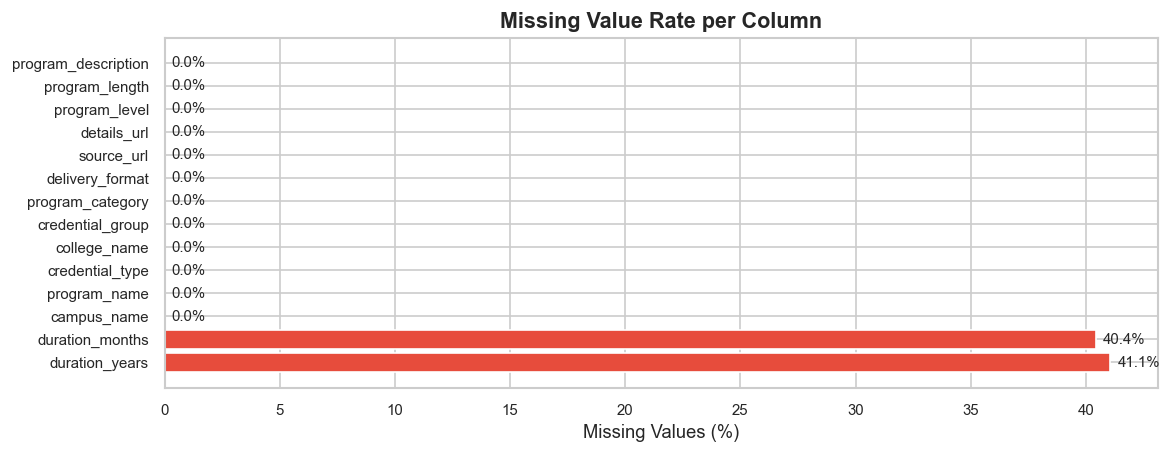

Red = >20% missing | Orange = 5-20% | Green = <5%


In [4]:
# ── Replace 'Not Available' with NaN for numeric columns ─────────────────────
df['duration_months'] = pd.to_numeric(df['duration_months'], errors='coerce')
df['duration_years']  = pd.to_numeric(df['duration_years'],  errors='coerce')

null_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_pct.index, null_pct.values, color=[
    '#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#2ecc71'
    for v in null_pct.values
])
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Rate per Column', fontweight='bold')
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Red = >20% missing | Orange = 5-20% | Green = <5%')

## 4a. Program Category Distribution

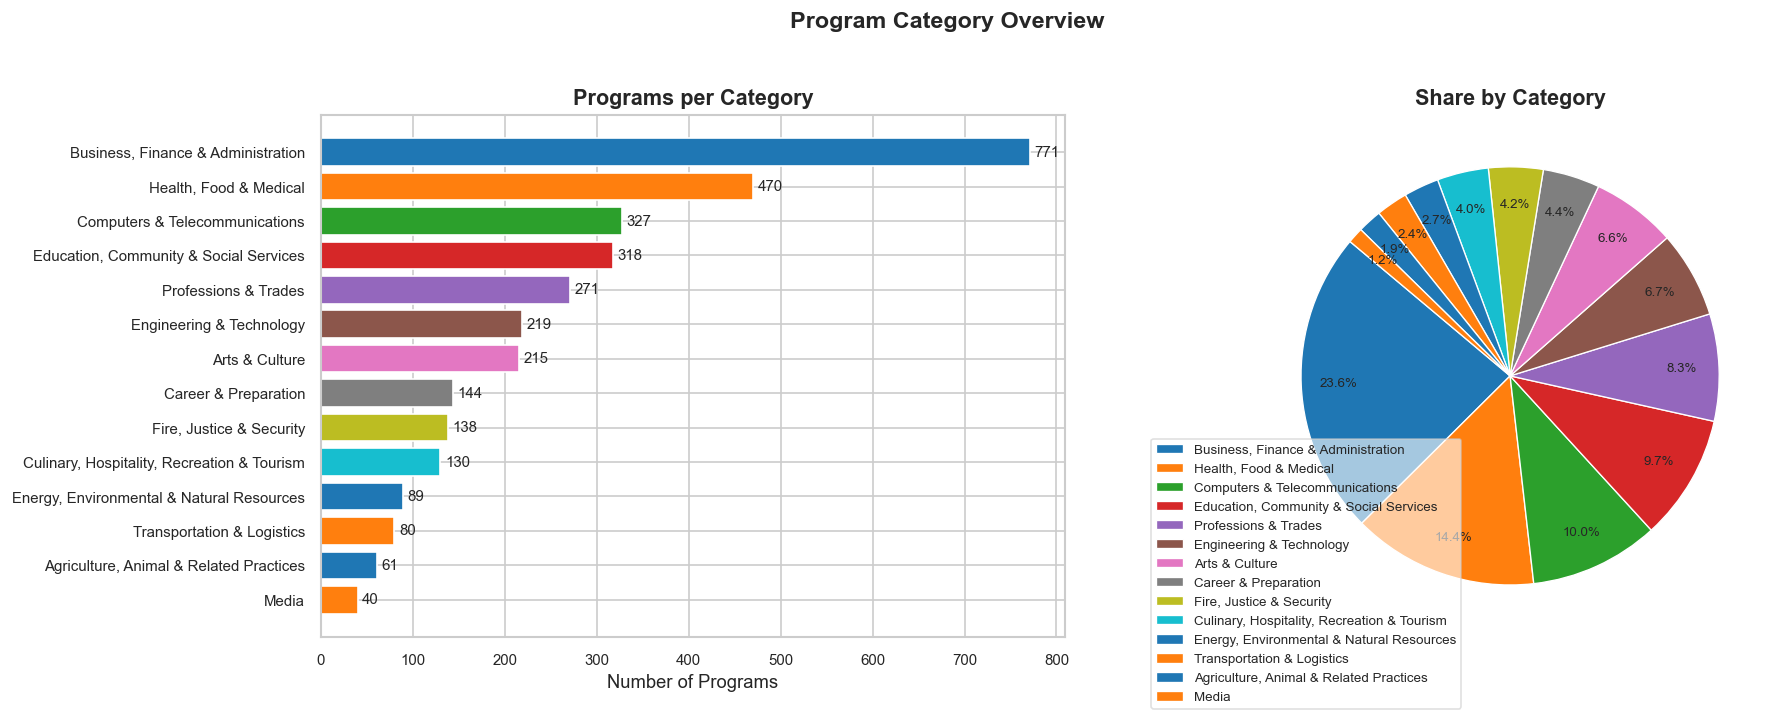

In [5]:
cat_counts = df['program_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Bar chart ────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=PALETTE_CAT[:len(cat_counts)])
ax.set_xlabel('Number of Programs')
ax.set_title('Programs per Category', fontweight='bold')
ax.invert_yaxis()
for bar, v in zip(bars, cat_counts.values):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    cat_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=PALETTE_CAT[:len(cat_counts)],
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'}
)
for at in autotexts: at.set_fontsize(8)
ax2.legend(wedges, cat_counts.index, loc='lower left',
           fontsize=8, framealpha=0.6, bbox_to_anchor=(-0.2, -0.15))
ax2.set_title('Share by Category', fontweight='bold')

plt.suptitle('Program Category Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4b. Credential Type & Credential Group

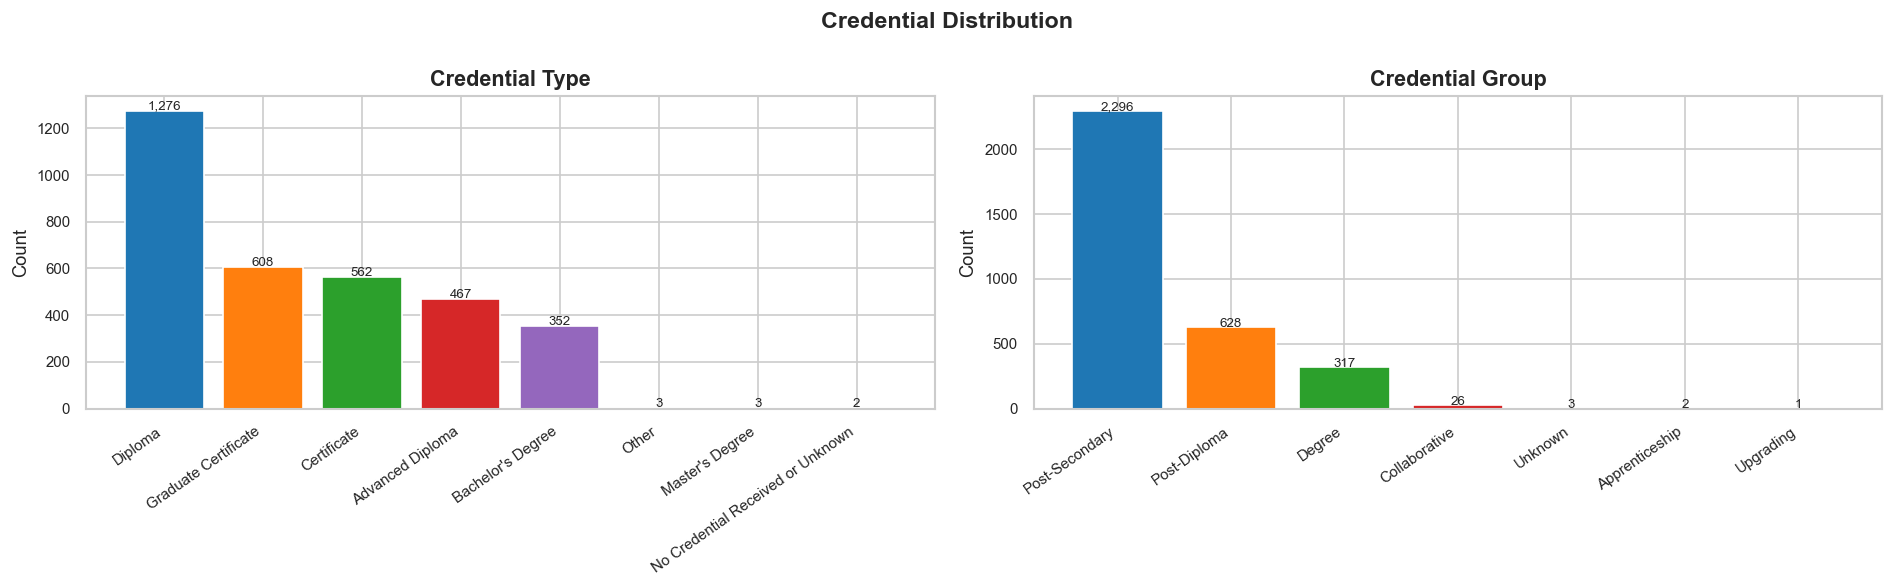

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(axes,
                          ['credential_type', 'credential_group'],
                          ['Credential Type', 'Credential Group']):
    counts = df[col].value_counts()
    ax.bar(range(len(counts)), counts.values,
           color=PALETTE_CAT[:len(counts)], edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Credential Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4c. Delivery Format

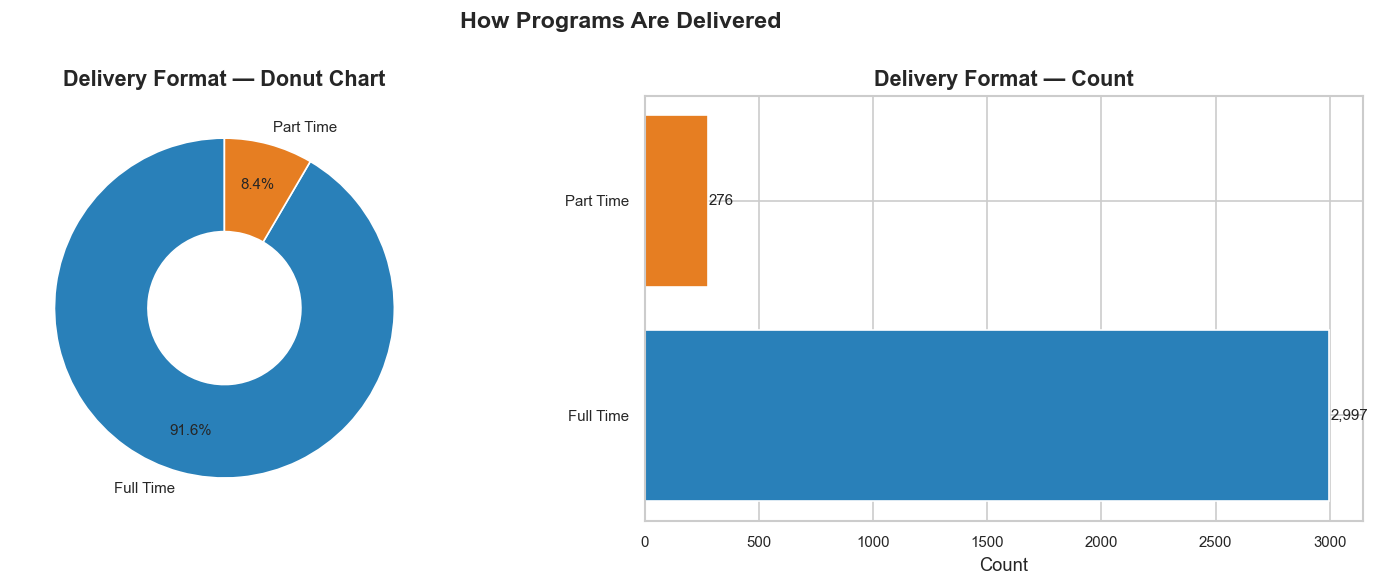

In [7]:
del_counts = df['delivery_format'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Donut ────────────────────────────────────────────────────────────────────
wedges, _, autotexts = axes[0].pie(
    del_counts.values,
    labels=del_counts.index,
    autopct='%1.1f%%',
    colors=['#2980b9', '#e67e22', '#27ae60', '#8e44ad', '#c0392b'],
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white'},
    pctdistance=0.75
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('Delivery Format — Donut Chart', fontweight='bold')

# ── Horizontal bar ────────────────────────────────────────────────────────────
axes[1].barh(del_counts.index, del_counts.values,
             color=['#2980b9', '#e67e22', '#27ae60', '#8e44ad', '#c0392b'])
axes[1].set_xlabel('Count')
axes[1].set_title('Delivery Format — Count', fontweight='bold')
for i, v in enumerate(del_counts.values):
    axes[1].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('How Programs Are Delivered', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4d. Program Level

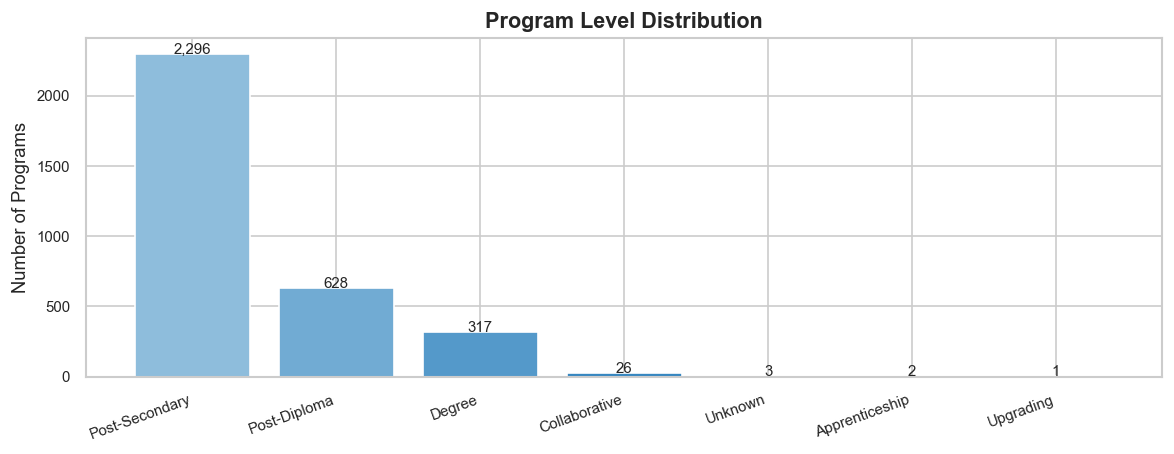

In [8]:
lvl = df['program_level'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
colors = sns.color_palette('Blues_d', len(lvl))
bars = ax.bar(lvl.index, lvl.values, color=colors, edgecolor='white')
ax.set_ylabel('Number of Programs')
ax.set_title('Program Level Distribution', fontweight='bold')
for bar, v in zip(bars, lvl.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, f'{v:,}',
            ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 4e. Program Duration Distribution

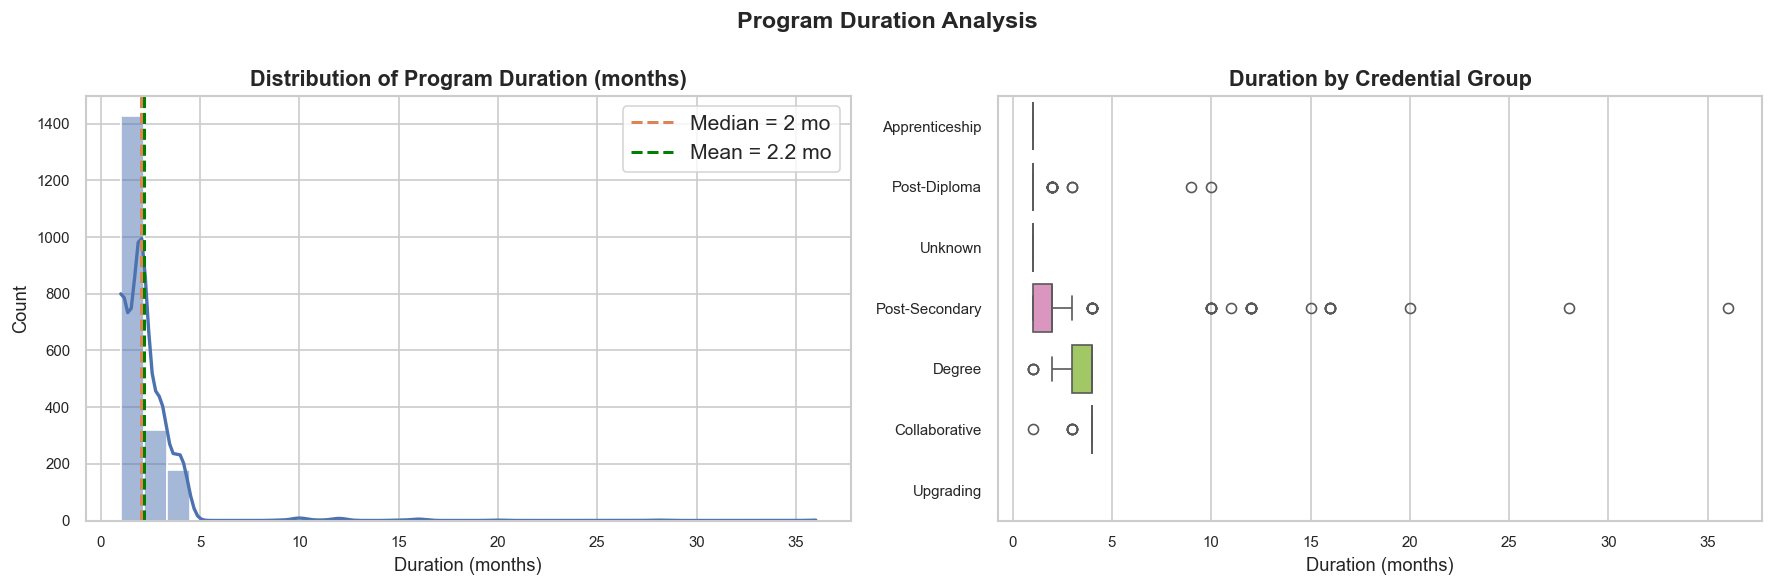

In [9]:
dur_valid = df['duration_months'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(dur_valid, bins=30, kde=True, color=MAIN_COLOR,
             edgecolor='white', ax=axes[0], line_kws={'lw': 2})
axes[0].axvline(dur_valid.median(), color=ACCENT, ls='--', lw=1.8,
                label=f'Median = {dur_valid.median():.0f} mo')
axes[0].axvline(dur_valid.mean(), color='green', ls='--', lw=1.8,
                label=f'Mean = {dur_valid.mean():.1f} mo')
axes[0].legend()
axes[0].set_xlabel('Duration (months)')
axes[0].set_title('Distribution of Program Duration (months)', fontweight='bold')

# ── Box plot by credential group ─────────────────────────────────────────────
cred_order = df.groupby('credential_group')['duration_months'].median().sort_values().index
sns.boxplot(data=df.dropna(subset=['duration_months']),
            y='credential_group', x='duration_months',
            order=cred_order, palette='Set2', ax=axes[1])
axes[1].set_xlabel('Duration (months)')
axes[1].set_ylabel('')
axes[1].set_title('Duration by Credential Group', fontweight='bold')

plt.suptitle('Program Duration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. College-Level Analysis

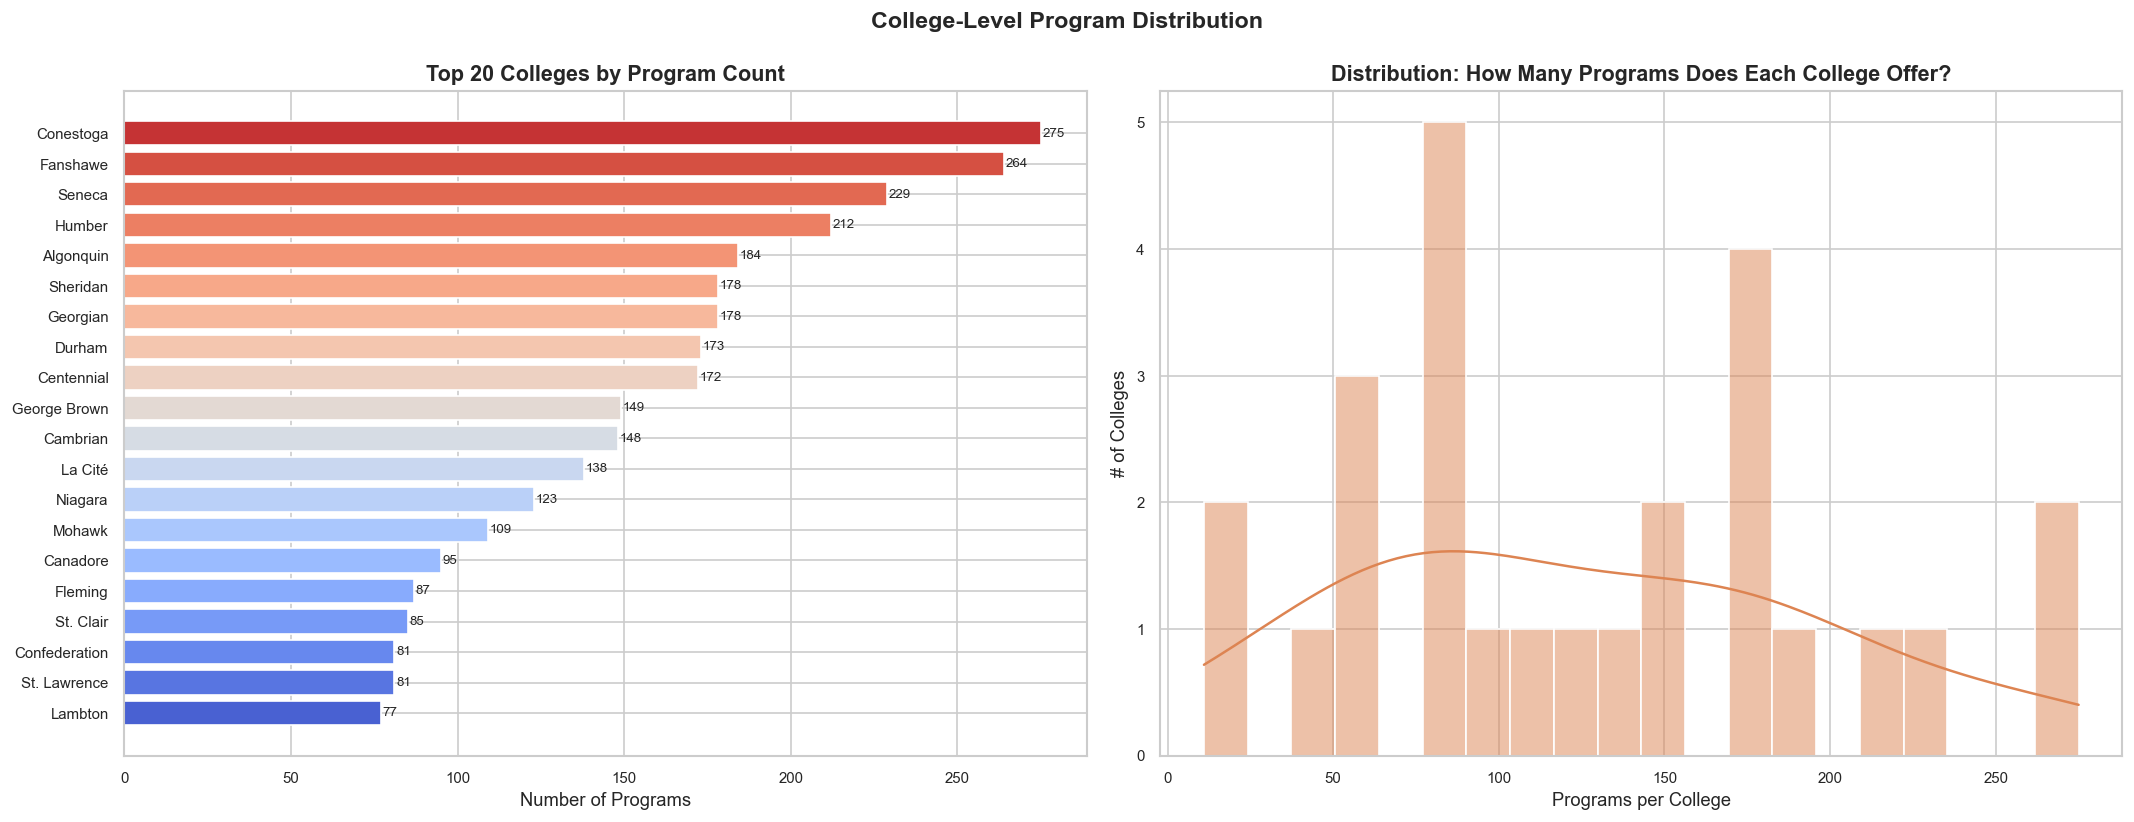

In [10]:
college_counts = df['college_name'].value_counts()
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top N Colleges by program count ──────────────────────────────────────────
top = college_counts.head(top_n)
colors_grad = sns.color_palette('coolwarm', top_n)
axes[0].barh(top.index[::-1], top.values[::-1], color=colors_grad)
axes[0].set_xlabel('Number of Programs')
axes[0].set_title(f'Top {top_n} Colleges by Program Count', fontweight='bold')
for i, v in enumerate(top.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# ── Programs per College — distribution ──────────────────────────────────────
sns.histplot(college_counts.values, bins=20, kde=True,
             color=ACCENT, edgecolor='white', ax=axes[1])
axes[1].set_xlabel('Programs per College')
axes[1].set_ylabel('# of Colleges')
axes[1].set_title('Distribution: How Many Programs Does Each College Offer?',
                  fontweight='bold')

plt.suptitle('College-Level Program Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

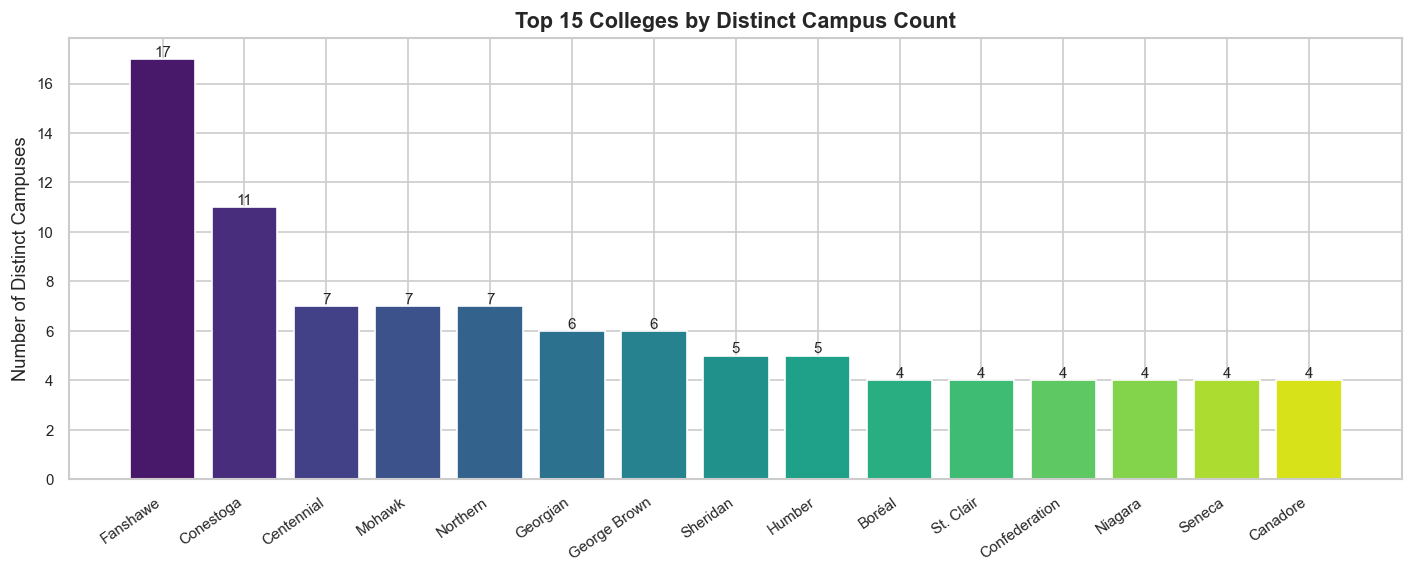

In [11]:
# ── Campus count per college ──────────────────────────────────────────────────
campuses_per_college = df.groupby('college_name')['campus_name'].nunique().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(campuses_per_college.index, campuses_per_college.values,
              color=sns.color_palette('viridis', len(campuses_per_college)))
ax.set_ylabel('Number of Distinct Campuses')
ax.set_title('Top 15 Colleges by Distinct Campus Count', fontweight='bold')
ax.set_xticklabels(campuses_per_college.index, rotation=35, ha='right')
for bar, v in zip(bars, campuses_per_college.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v),
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6a. Category × Credential Type — Stacked Bar

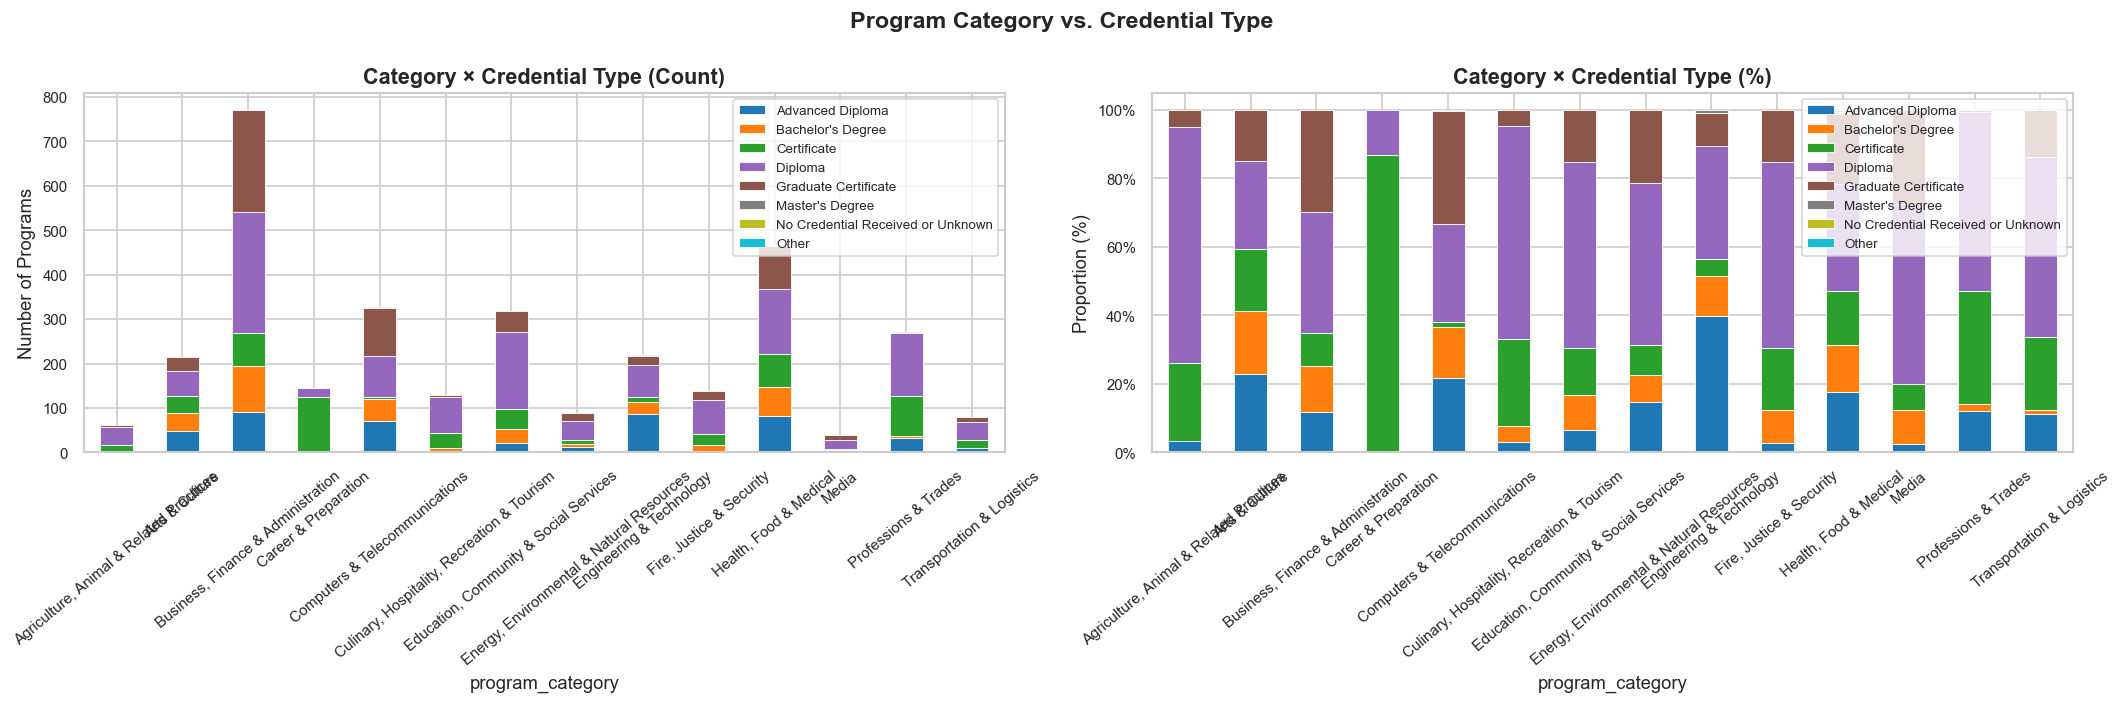

In [12]:
cross = pd.crosstab(df['program_category'], df['credential_type'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Absolute counts ───────────────────────────────────────────────────────────
cross.plot(kind='bar', stacked=True,
           colormap='tab10', ax=axes[0], edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Number of Programs')
axes[0].set_title('Category × Credential Type (Count)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=40)

# ── Percentage ────────────────────────────────────────────────────────────────
cross_pct.plot(kind='bar', stacked=True,
               colormap='tab10', ax=axes[1], edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('Proportion (%)')
axes[1].set_title('Category × Credential Type (%)', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=40)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Program Category vs. Credential Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6b. Heatmap — Top Colleges × Categories

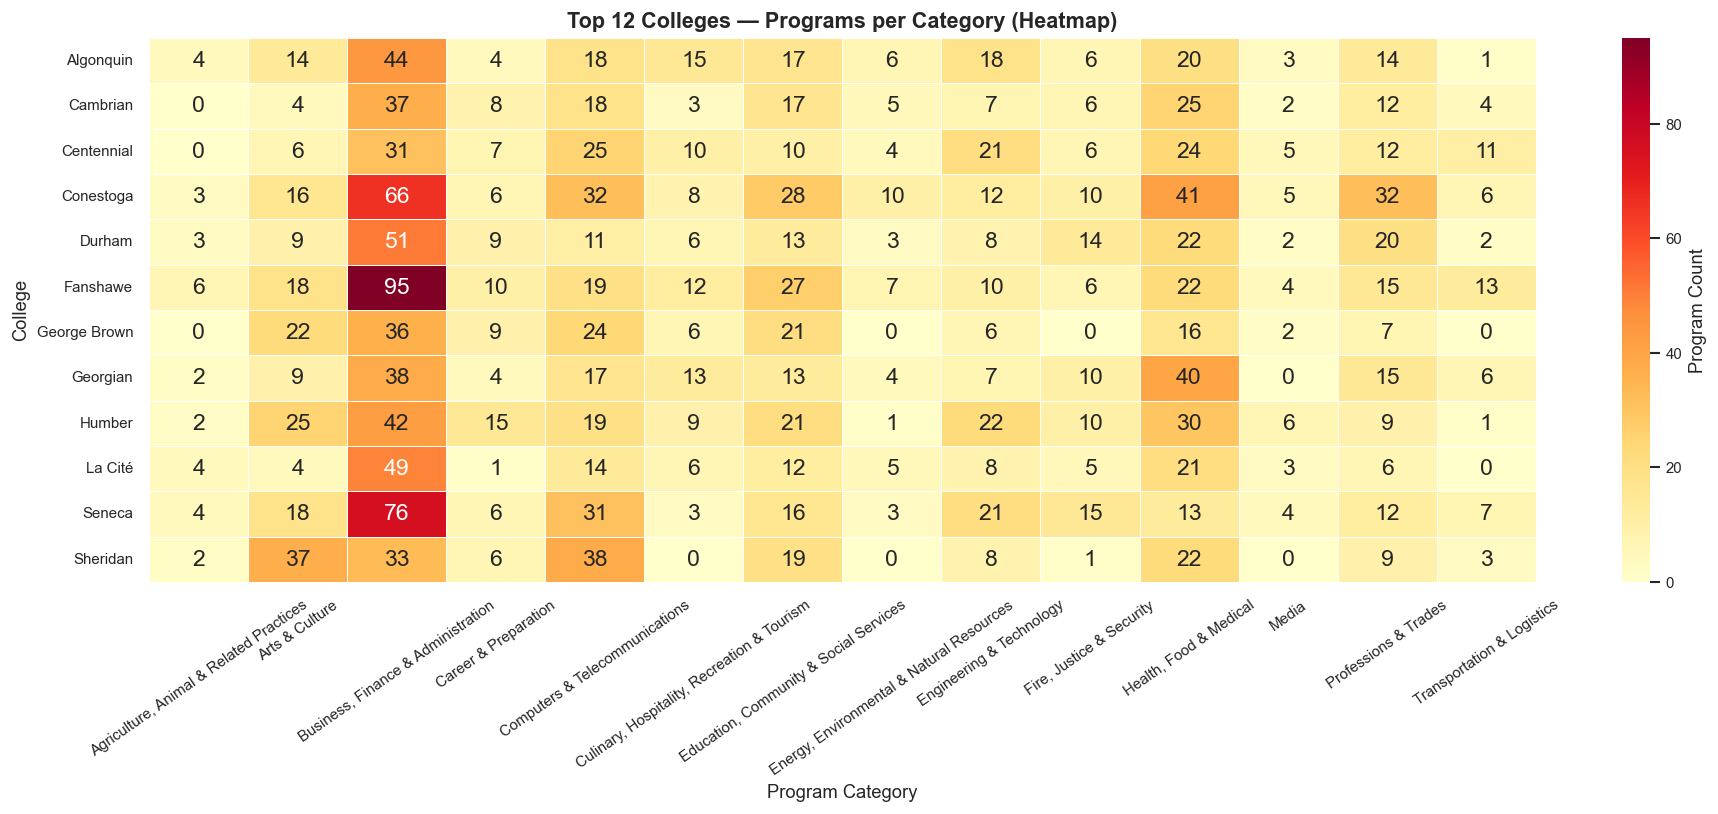

In [13]:
top_colleges = df['college_name'].value_counts().head(12).index
heat_data = pd.crosstab(
    df[df['college_name'].isin(top_colleges)]['college_name'],
    df[df['college_name'].isin(top_colleges)]['program_category']
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Program Count'},
            ax=ax)
ax.set_title('Top 12 Colleges — Programs per Category (Heatmap)', fontweight='bold', fontsize=13)
ax.set_xlabel('Program Category')
ax.set_ylabel('College')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 6c. Delivery Format by College (Top 10)

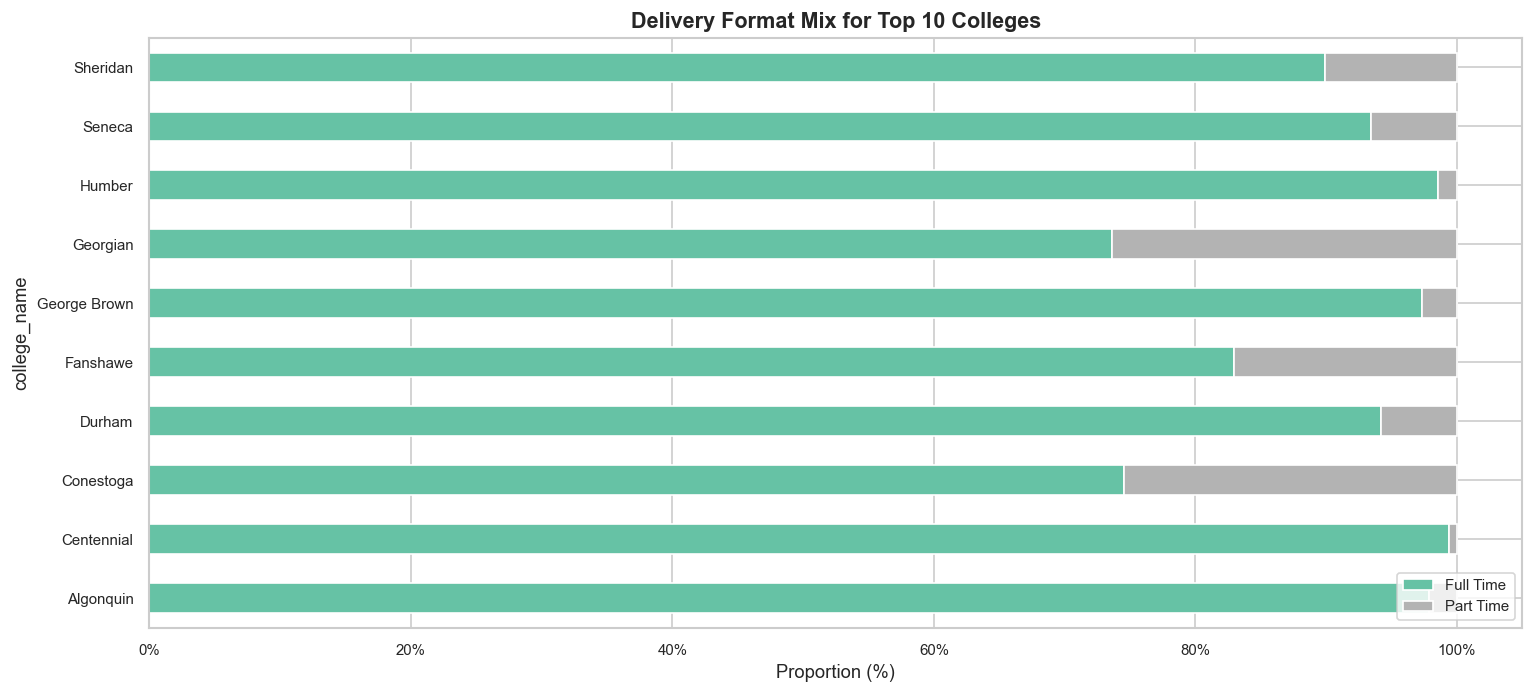

In [14]:
top10 = df['college_name'].value_counts().head(10).index
df_top = df[df['college_name'].isin(top10)]
del_college = pd.crosstab(df_top['college_name'], df_top['delivery_format'])
del_pct = del_college.div(del_college.sum(axis=1), axis=0) * 100

ax = del_pct.plot(kind='barh', stacked=True,
                  colormap='Set2', figsize=(13, 6),
                  edgecolor='white')
ax.set_xlabel('Proportion (%)')
ax.set_title('Delivery Format Mix for Top 10 Colleges', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6d. Duration by Credential Type — Violin Plot

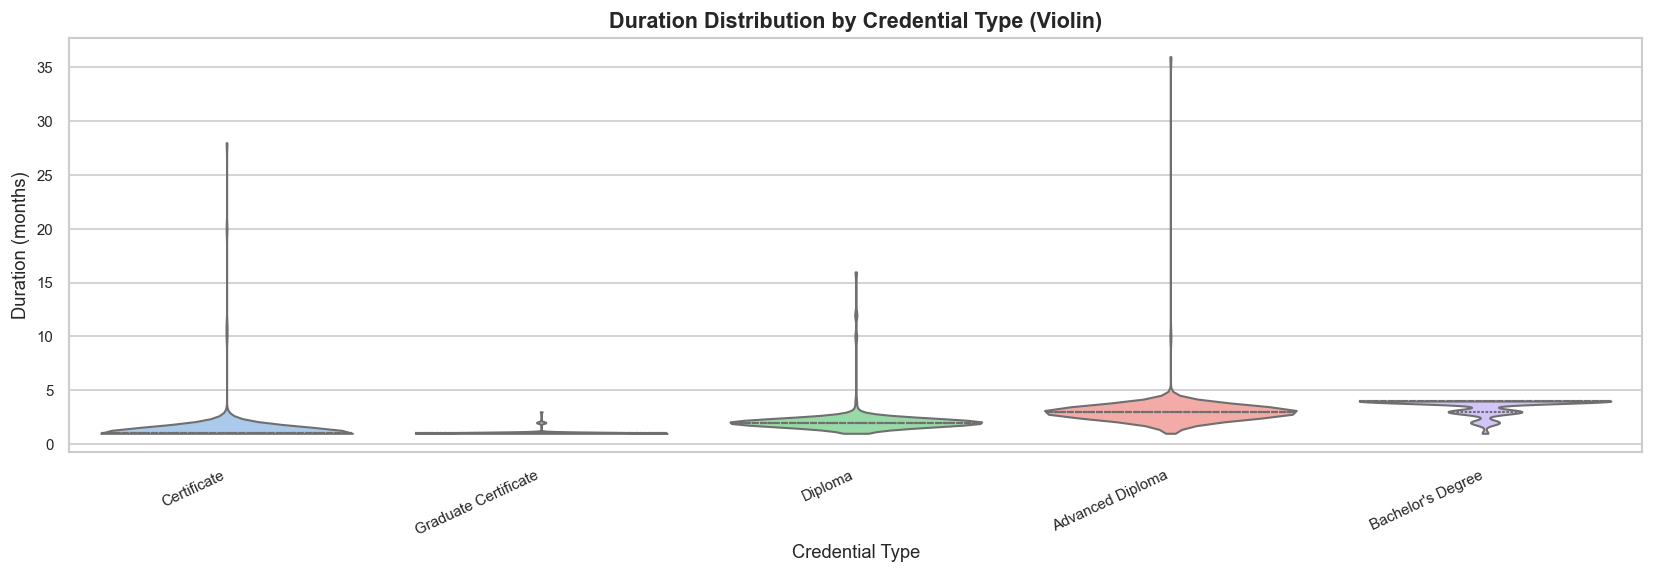

In [15]:
dur_df = df.dropna(subset=['duration_months'])
order = dur_df.groupby('credential_type')['duration_months'].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=dur_df, x='credential_type', y='duration_months',
               order=order, palette='pastel',
               inner='quartile', cut=0, ax=ax)
ax.set_xlabel('Credential Type')
ax.set_ylabel('Duration (months)')
ax.set_title('Duration Distribution by Credential Type (Violin)', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 7. Program Description — NLP Word Frequency

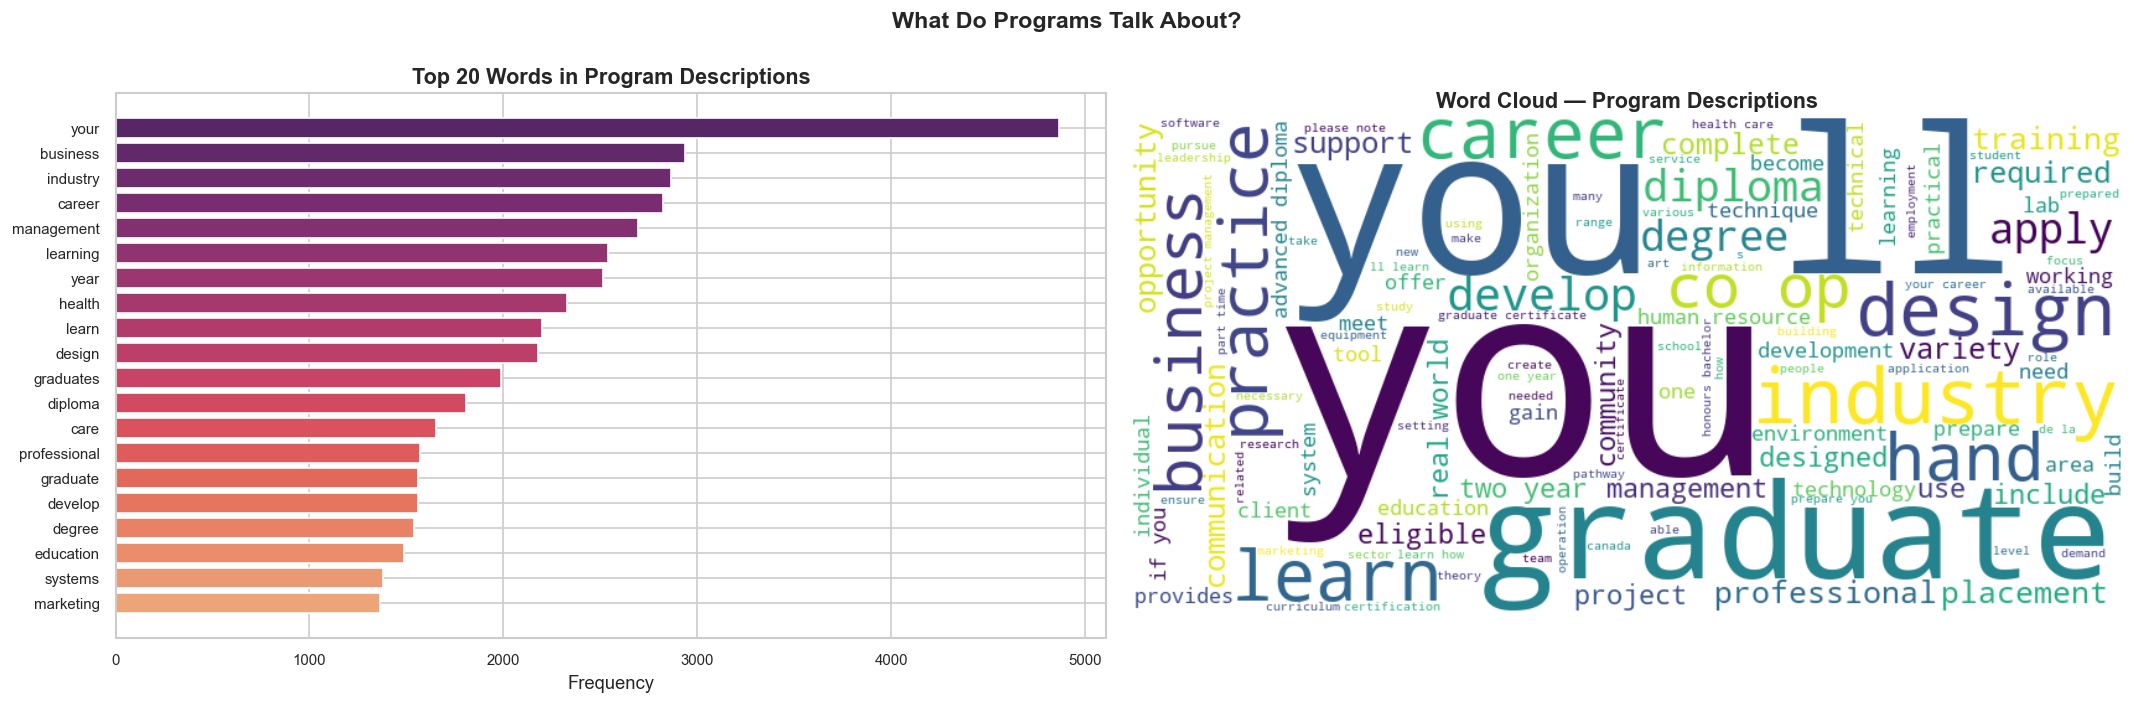

In [16]:
from wordcloud import WordCloud

STOPWORDS = {
    'the','and','of','to','a','in','is','for','with','that','are','this',
    'will','be','an','as','their','have','they','from','or','on','at','by',
    'which','has','not','also','can','who','its','all','our','it','into',
    'these','been','may','more','other','students','program','programs',
    'ontario','college','skills','knowledge','work','including','well',
    'upon','through','provide','ability','within','such','both','about',
    'while','between','opportunities','during','course','courses','field',
    'completion','further','experience'
}

all_text = ' '.join(df['program_description'].dropna().astype(str))
all_text_clean = re.sub(r'[^a-zA-Z\s]', ' ', all_text).lower()
words = [w for w in all_text_clean.split() if len(w) > 3 and w not in STOPWORDS]

freq = Counter(words).most_common(40)
freq_df = pd.DataFrame(freq, columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Top-40 bar chart ──────────────────────────────────────────────────────────
top20 = freq_df.head(20)
axes[0].barh(top20['word'][::-1], top20['count'][::-1],
             color=sns.color_palette('flare', 20))
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Words in Program Descriptions', fontweight='bold')

# ── Word cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='viridis', max_words=120,
               stopwords=STOPWORDS).generate(all_text_clean)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Program Descriptions', fontweight='bold')

plt.suptitle('What Do Programs Talk About?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7b. Top Skills / Tech Keywords Mentioned in Descriptions

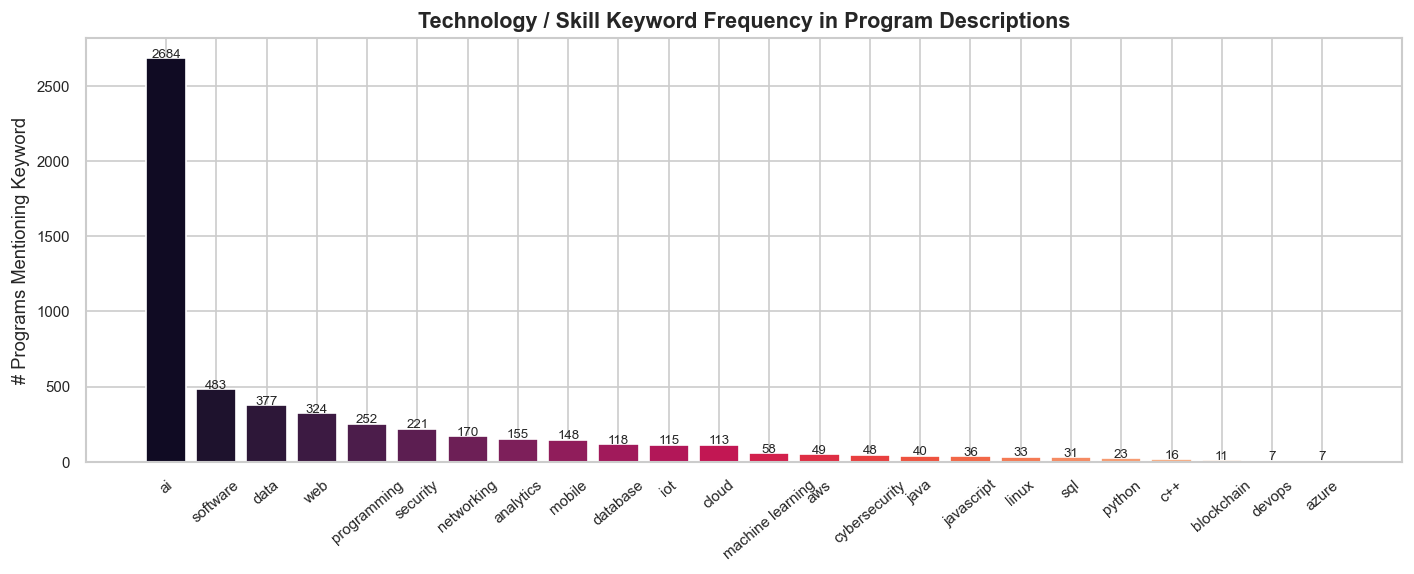

In [17]:
TECH_KEYWORDS = [
    'python', 'java', 'sql', 'cloud', 'networking', 'security', 'linux',
    'database', 'cybersecurity', 'data', 'machine learning', 'ai',
    'web', 'software', 'programming', 'devops', 'azure', 'aws',
    'javascript', 'c++', 'mobile', 'analytics', 'iot', 'blockchain'
]

desc_lower = df['program_description'].fillna('').str.lower()
kw_counts = {kw: desc_lower.str.contains(kw, regex=False).sum() for kw in TECH_KEYWORDS}
kw_series = pd.Series(kw_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(kw_series.index, kw_series.values,
              color=sns.color_palette('rocket', len(kw_series)))
ax.set_ylabel('# Programs Mentioning Keyword')
ax.set_title('Technology / Skill Keyword Frequency in Program Descriptions',
             fontweight='bold')
ax.tick_params(axis='x', rotation=40)
for bar, v in zip(bars, kw_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5,
            str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Numeric Summary & Correlation

=== Descriptive Statistics (numeric columns) ===


,duration_months,duration_years,program_length
count,1950.00,1929.00,3273.00
mean,2.17,2.04,3.32
std,1.74,1.12,4.27
min,1.00,1.00,0.00
25%,1.00,1.00,2.00
50%,2.00,2.00,2.00
75%,3.00,3.00,4.00
max,36.00,28.00,52.00


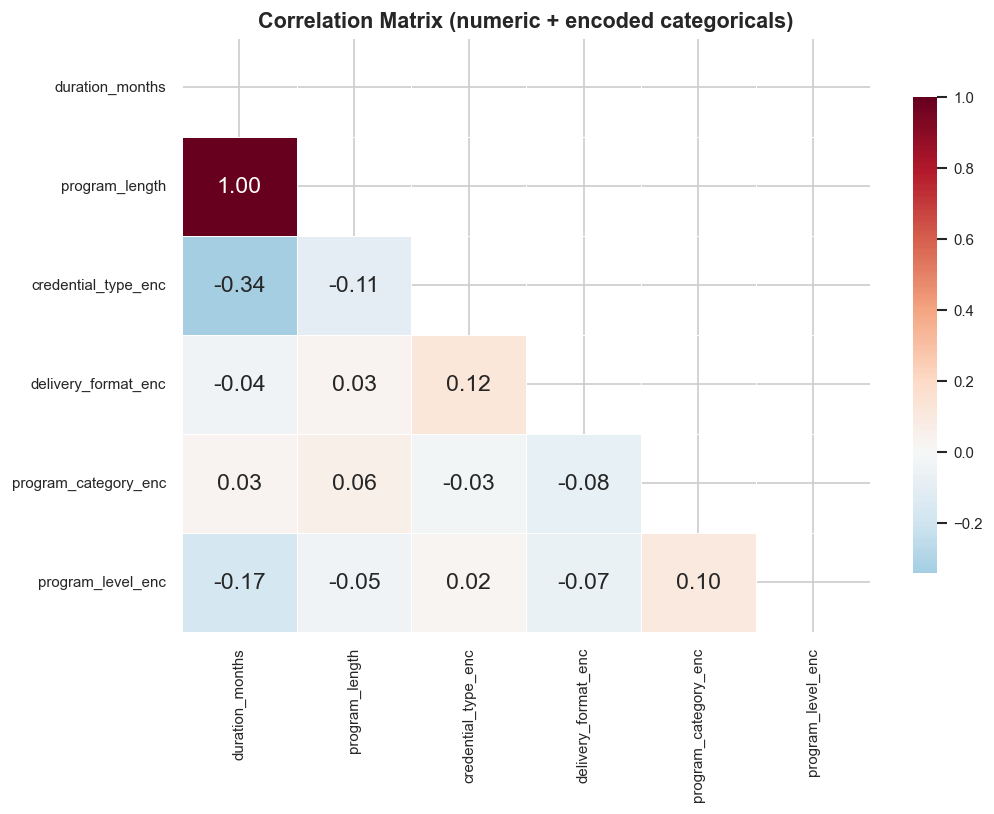

In [18]:
# ── Numeric statistics ────────────────────────────────────────────────────────
print('=== Descriptive Statistics (numeric columns) ===')
display(df[['duration_months', 'duration_years', 'program_length']].describe().round(2))

# ── Encode some categoricals for correlation ──────────────────────────────────
df_enc = df.copy()
for col in ['credential_type', 'delivery_format', 'program_category', 'program_level']:
    df_enc[col + '_enc'] = df[col].astype('category').cat.codes

num_cols = ['duration_months', 'program_length',
            'credential_type_enc', 'delivery_format_enc',
            'program_category_enc', 'program_level_enc']
corr = df_enc[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix (numeric + encoded categoricals)',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 8b. Programs per College — Ranked Lollipop Chart (Top 25)

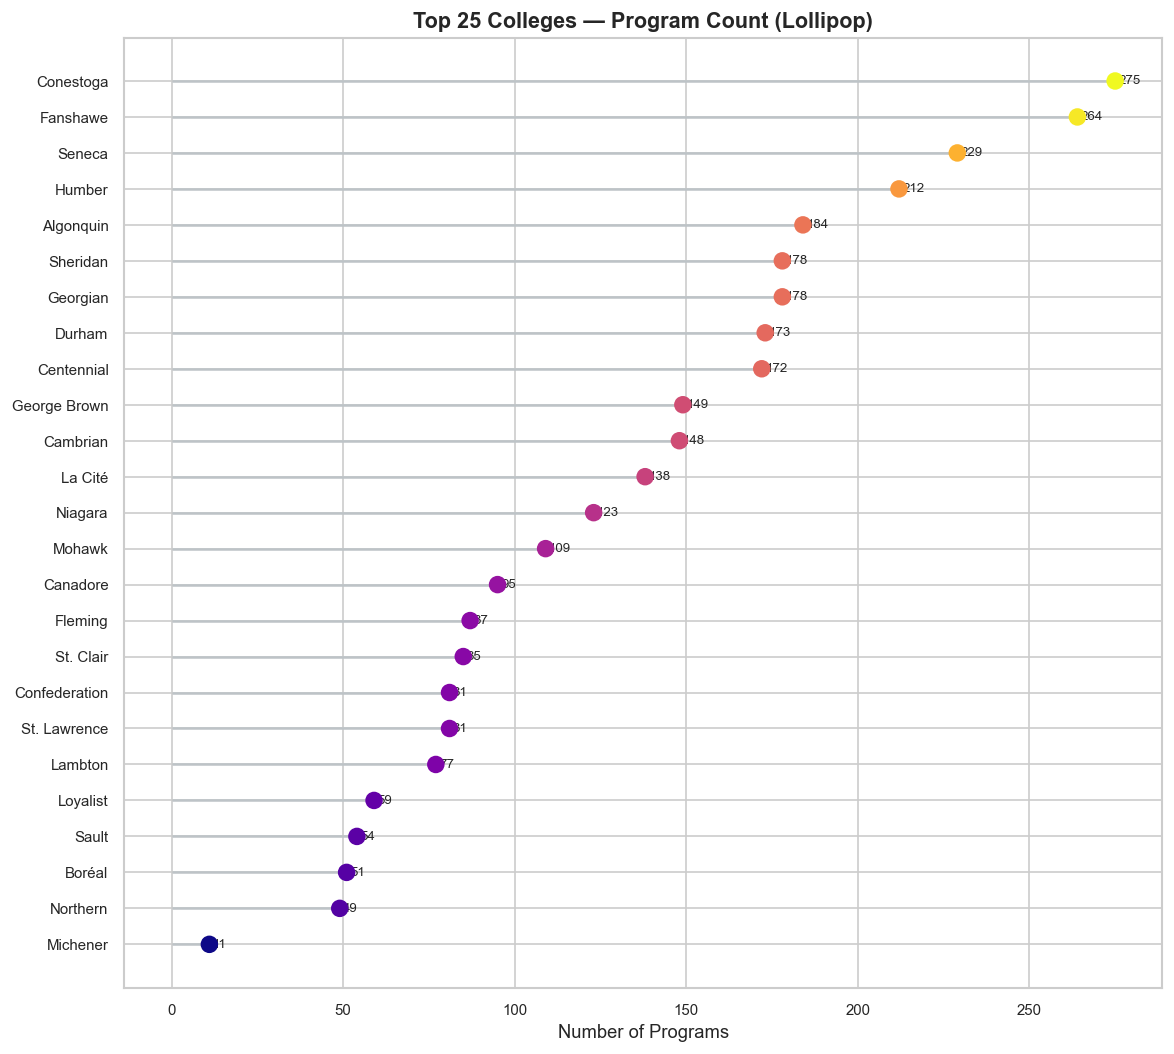

In [19]:
top25 = df['college_name'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 9))
ax.hlines(range(len(top25)), 0, top25.values, colors='#bdc3c7', linewidths=1.5)
ax.scatter(top25.values, range(len(top25)),
           s=90, zorder=5,
           c=top25.values, cmap='plasma')
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=9)
ax.set_xlabel('Number of Programs')
ax.set_title('Top 25 Colleges — Program Count (Lollipop)', fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(top25.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Key Insights & Takeaways

In [20]:
total_programs   = len(df)
total_colleges   = df['college_name'].nunique()
total_campuses   = df['campus_name'].nunique()
total_categories = df['program_category'].nunique()
top_cat          = df['program_category'].value_counts().idxmax()
top_cat_pct      = df['program_category'].value_counts(normalize=True).max()*100
top_cred         = df['credential_type'].value_counts().idxmax()
top_college      = df['college_name'].value_counts().idxmax()
ft_pct           = (df['delivery_format']=='Full Time').mean()*100
median_dur       = df['duration_months'].median()

print('=' * 55)
print('          DATASET SUMMARY & KEY INSIGHTS')
print('=' * 55)
print(f'  Total Programs      : {total_programs:,}')
print(f'  Colleges            : {total_colleges}')
print(f'  Campuses            : {total_campuses}')
print(f'  Program Categories  : {total_categories}')
print(f'  Top Category        : {top_cat!r} ({top_cat_pct:.1f}%)')
print(f'  Top Credential Type : {top_cred!r}')
print(f'  Largest College     : {top_college!r}')
print(f'  Full-Time Programs  : {ft_pct:.1f}%')
print(f'  Median Duration     : {median_dur:.0f} months')
print('=' * 55)
print()
print('Actionable Insights:')
print('  1. Most programs are Full-Time — Part-Time is a minority.')
print('  2. Ontario college programs span IT, Business, Health, etc.')
print('     → Recommendation engine must handle cross-category noise.')
print('  3. duration_months has significant missing data (~needs impute).')
print('  4. "Data", "software", "security" dominate descriptions')
print('     → these are strong features for a TF-IDF / embedding model.')
print('  5. College program counts are skewed — a few large colleges')
print('     account for a disproportionate share of offerings.')

          DATASET SUMMARY & KEY INSIGHTS
  Total Programs      : 3,273
  Colleges            : 26
  Campuses            : 111
  Program Categories  : 14
  Top Category        : 'Business, Finance & Administration' (23.6%)
  Top Credential Type : 'Diploma'
  Largest College     : 'Conestoga'
  Full-Time Programs  : 91.6%
  Median Duration     : 2 months

Actionable Insights:
  1. Most programs are Full-Time — Part-Time is a minority.
  2. Ontario college programs span IT, Business, Health, etc.
     → Recommendation engine must handle cross-category noise.
  3. duration_months has significant missing data (~needs impute).
  4. "Data", "software", "security" dominate descriptions
     → these are strong features for a TF-IDF / embedding model.
  5. College program counts are skewed — a few large colleges
     account for a disproportionate share of offerings.
